# Credit Default Case — Update 2


## Load csv and imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os
# from google.colab import files
import io

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

data_path = "../../data/loanskpi.csv"

try:
    df = pd.read_csv(data_path)
    print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
    display(df.head())
except FileNotFoundError:
    print(f"File not found at {data_path}. Please upload 'loanskpi.csv'.")
    uploaded = files.upload()

    found_file = None
    for filename in uploaded.keys():
        if filename.startswith('loanskpi') and filename.endswith('.csv'):
            found_file = filename
            break

    if found_file:
        df = pd.read_csv(io.BytesIO(uploaded[found_file]))
        print(f"Successfully loaded '{found_file}'.")
        print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
        display(df.head())
    else:
        print("No file starting with 'loanskpi' and ending with '.csv' was uploaded. Please ensure you upload the correct file.")

Shape: 9578 rows x 17 columns


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,default,tot.payment,principal,interest
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,29847.60,20892.796502,8954.803498
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,8215.92,5958.231659,2257.688341
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,13206.96,8790.257126,4416.702874
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,5844.24,4319.141090,1525.098910
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,3705.12,2415.522565,1289.597435


# 1. Logistic Regression

## 1.1. Correlations between variables

We look at pairwise linear relationships among the numeric loan variables,
then zoom in on two pairs of interest: interest rate vs. FICO score, and
revolving balance vs. revolving utilization.

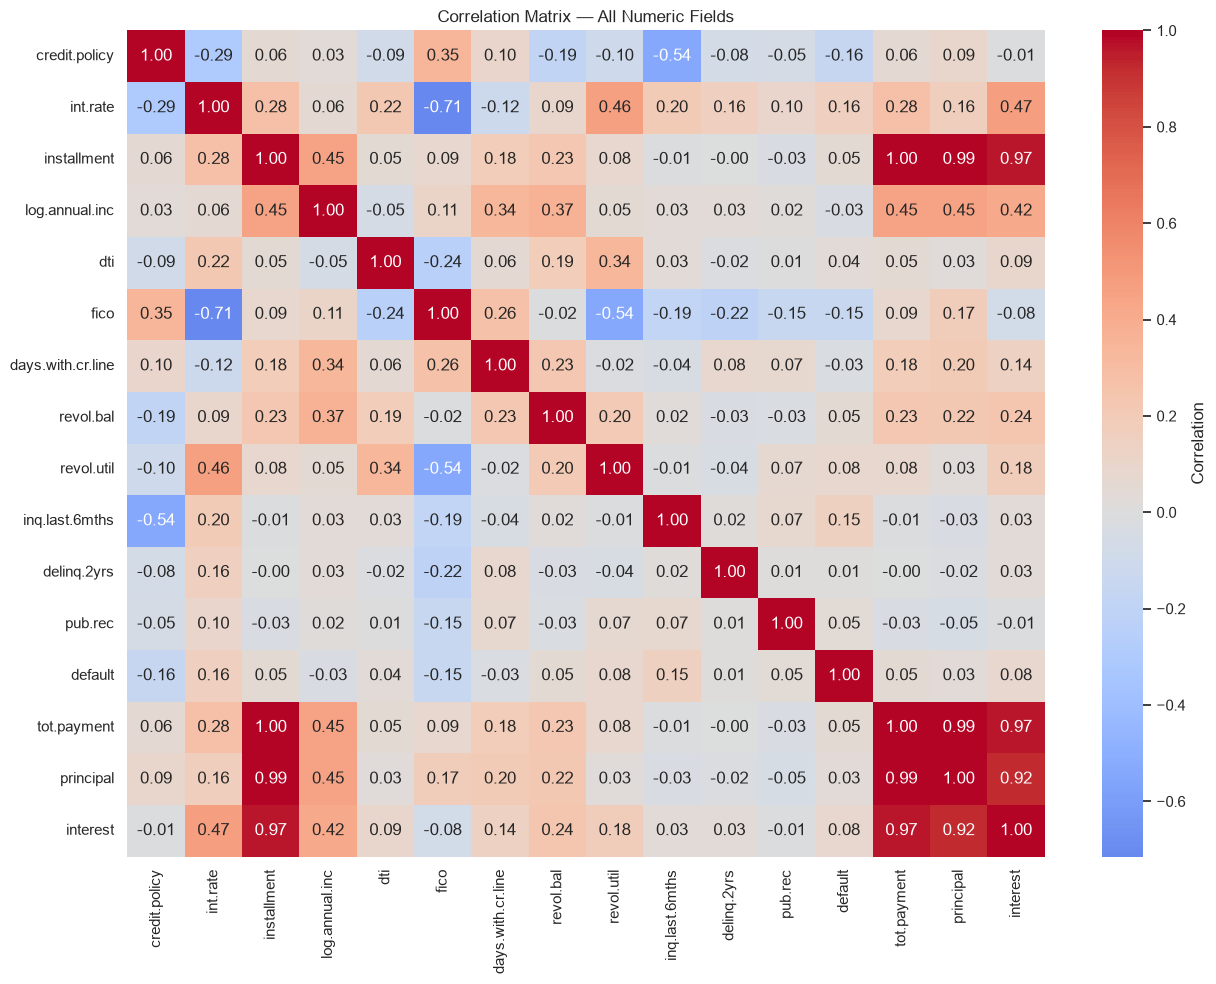

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — All Numeric Fields')
plt.tight_layout()
plt.show()

In [4]:
top_n = 15
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename('correlation')
        .reset_index()
        .rename(columns={'level_0': 'var_1', 'level_1': 'var_2'})
)
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.sort_values('abs_correlation', ascending=False).drop(columns='abs_correlation')

display(corr_pairs.head(top_n).reset_index(drop=True))

,var_1,var_2,correlation
0,installment,tot.payment,1.000000
1,tot.payment,principal,0.990172
2,installment,principal,0.990172
3,installment,interest,0.966023
4,tot.payment,interest,0.966023
5,principal,interest,0.920382
6,int.rate,fico,-0.714821
7,fico,revol.util,-0.541289
8,credit.policy,inq.last.6mths,-0.535511
9,int.rate,interest,0.471355


### 1.1.1 Interest rate vs. FICO score

Correlation (int.rate, fico): -0.715


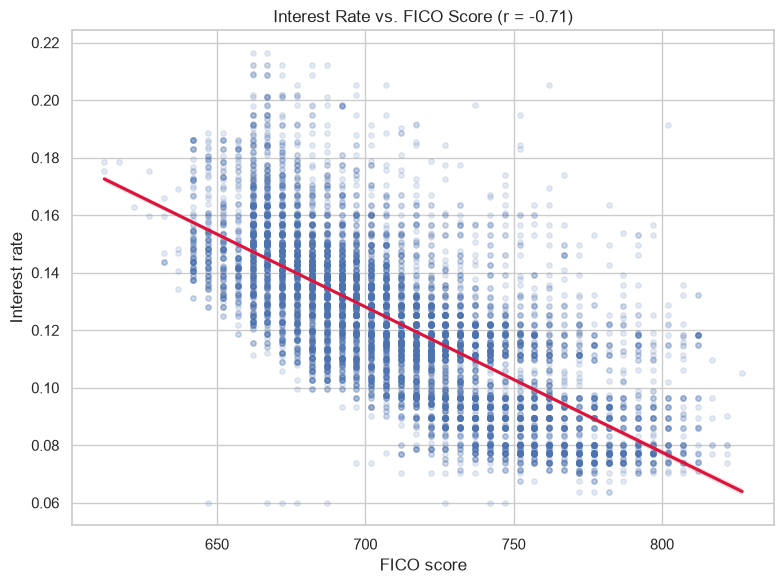

In [5]:
r_rate_fico = df['int.rate'].corr(df['fico'])
print(f"Correlation (int.rate, fico): {r_rate_fico:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='fico', y='int.rate', scatter_kws={'alpha': 0.15, 's': 15},
            line_kws={'color': 'crimson'})
plt.title(f'Interest Rate vs. FICO Score (r = {r_rate_fico:.2f})')
plt.xlabel('FICO score')
plt.ylabel('Interest rate')
plt.tight_layout()
plt.show()

### 1.1.2 Revolving balance vs. revolving utilization

Correlation (revol.bal, revol.util), full data: 0.204


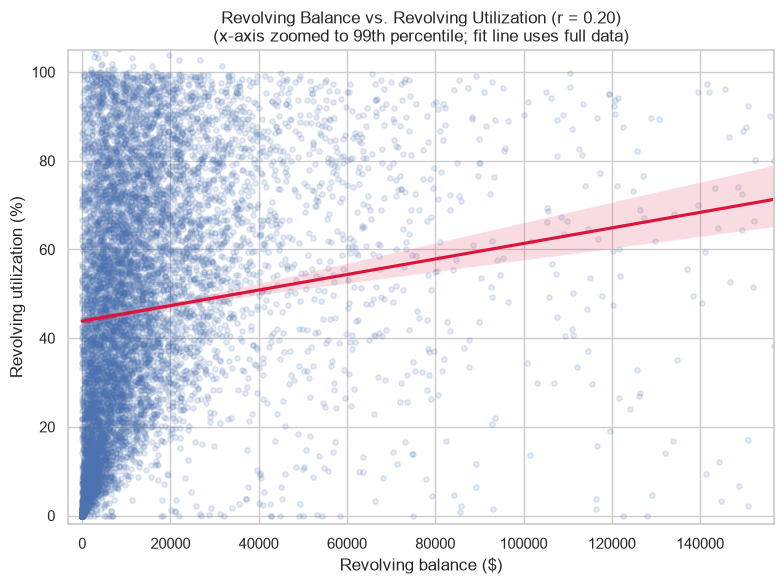

In [6]:
r_bal_util = df['revol.bal'].corr(df['revol.util'])
print(f"Correlation (revol.bal, revol.util), full data: {r_bal_util:.3f}")

x_cap = df['revol.bal'].quantile(0.99)
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='revol.bal', y='revol.util', scatter_kws={'alpha': 0.15, 's': 15},
            line_kws={'color': 'crimson'})
plt.xlim(-x_cap * 0.02, x_cap)
plt.ylim(-2, 105)
plt.title(f'Revolving Balance vs. Revolving Utilization (r = {r_bal_util:.2f})\n'
          f'(x-axis zoomed to 99th percentile; fit line uses full data)')
plt.xlabel('Revolving balance ($)')
plt.ylabel('Revolving utilization (%)')
plt.tight_layout()
plt.show()

## 1.2.Choosing the variable set for the logistic regression

We build the default model only from information Lending Club actually has
**at the time of the loan application** — anything computed after the loan
plays out cannot be used to screen new applications. We then use the
correlation analysis above to avoid feeding the model redundant,
near-duplicate signals.

**Step 1 — drop post-outcome variables.** `tot.payment`, `principal`, and
`interest` are only known once a loan has been repaid (or defaulted), so
they are unusable for screening a new application and are excluded outright
regardless of how predictive they look in-sample.

**Step 2 — drop `credit.policy`.** This flag records whether Lending Club's
*own* rule-based policy would have approved the loan. Using it to predict
default would mean re-deriving a variant of the existing policy rather than
building an independent screening signal, so we leave it out of the
predictive feature set (though it remains useful later as a benchmark to
compare our model against).

**Step 3 — resolve the most highly correlated pair.** From the heatmap and
ranked table in Section 1, one application-time pair stands out well above
the rest:

- **`int.rate` vs. `fico`** (r ≈ -0.71): Lending Club sets `int.rate`
  *using* FICO (and other risk factors) as part of its own pricing model.
  Including both would let the model partly re-derive `fico` from
  `int.rate` (or vice versa), inflating apparent significance without
  adding independent information. Because `int.rate` is Lending Club's own
  risk-pricing output — closer to a restatement of risk than a cause of
  it — we keep the more primitive, independently-observed `fico` and drop
  `int.rate`.

Other pairs (e.g. `revol.bal` vs. `revol.util` at r ≈ 0.20, or `fico` vs.
`revol.util` at r ≈ -0.54, confirmed in Section 2.1 below) are moderate at
most and each variable in the pair captures a genuinely distinct concept
(e.g. absolute balance vs. utilization rate, or credit score vs. revolving
behavior), so we retain both members of those pairs rather than treating
them as redundant.

In [7]:
# All fields known at application time (excludes post-outcome fields and
# Lending Club's own policy flag, both discussed above)
post_outcome_vars = ['tot.payment', 'principal', 'interest']
policy_var = ['credit.policy']
application_time_vars = [c for c in numeric_cols if c not in post_outcome_vars + policy_var + ['default']]
print("Application-time candidate variables:")
print(application_time_vars)

Application-time candidate variables:
['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']


In [8]:
# Drop int.rate: it is Lending Club's own risk-based pricing output and is
# highly correlated with fico (r ~ -0.71); keeping both would double-count
# the same underlying risk signal.
model_vars = [c for c in application_time_vars if c != 'int.rate']

print("Final variable set for the logistic regression model:")
for v in model_vars:
    print(f"  - {v}")

Final variable set for the logistic regression model:
  - installment
  - log.annual.inc
  - dti
  - fico
  - days.with.cr.line
  - revol.bal
  - revol.util
  - inq.last.6mths
  - delinq.2yrs
  - pub.rec


### 1.2.1 Confirming the final set is not multicollinear

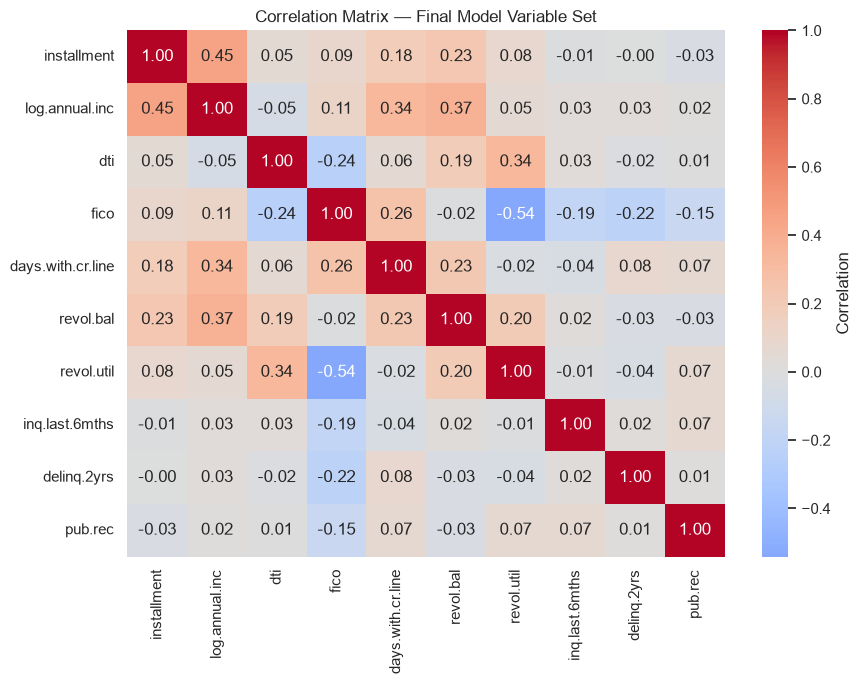

Largest remaining |correlation| among selected variables: 0.541


In [9]:
model_corr = df[model_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(model_corr, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix — Final Model Variable Set')
plt.tight_layout()
plt.show()

max_offdiag = model_corr.where(np.triu(np.ones(model_corr.shape), k=1).astype(bool)).abs().max().max()
print(f"Largest remaining |correlation| among selected variables: {max_offdiag:.3f}")

The strongest remaining pair is `fico` vs. `revol.util` (r ≈ -0.54) —
notable, but well short of the ~0.7 level that drove us to drop `int.rate`,
and conceptually distinct (a lender-assigned credit score vs. the
borrower's own revolving-credit behavior). We retain both.

**Final model variable set:** `installment`, `log.annual.inc`, `dti`,
`fico`, `days.with.cr.line`, `revol.bal`, `revol.util`, `inq.last.6mths`,
`delinq.2yrs`, `pub.rec` — ten application-time variables covering loan
size, income, indebtedness, credit quality, credit history length,
revolving credit exposure and utilization, and recent credit-seeking /
delinquency behavior, with no pair strongly enough correlated to be
considered redundant.

## 1.3.Logistic regression model

We split the data 80/20 into train and test sets (`random_state=42`) and
fit a logistic regression on the ten selected variables to predict
`default`.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, roc_auc_score, classification_report,
                              confusion_matrix)
import statsmodels.api as sm

RANDOM_SEED = 42

X = df[model_vars].copy()
y = df['default'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {X_train.shape[0]} loans ({y_train.mean()*100:.1f}% default)")
print(f"Test:  {X_test.shape[0]} loans ({y_test.mean()*100:.1f}% default)")

Train: 7662 loans (16.0% default)
Test:  1916 loans (16.0% default)


In [11]:
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=False)
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 7662
Model:                          Logit   Df Residuals:                     7651
Method:                           MLE   Df Model:                           10
Date:                Fri, 25 Sep 2026   Pseudo R-squ.:                 0.05228
Time:                        18:24:17   Log-Likelihood:                -3192.8
converged:                       True   LL-Null:                       -3368.9
Covariance Type:            nonrobust   LLR p-value:                 1.325e-69
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 9.2415      1.089      8.485      0.000       7.107      11.376
installment           0.0012      0.000      6.963      0.000       0.001       0.002
log.annual.inc       -0.

**Findings:** The model fits significantly better than an intercept-only
baseline (LLR p-value ≈ 1.3e-69) but pseudo-R² is low (~0.05), typical for
individual loan-level default prediction — most of the variance in who
defaults is simply not explained by these application-time variables
alone. Five of ten variables are significant at the 5% level: `fico`
(negative — higher credit score, lower default risk), `log.annual.inc`
(negative — higher income, lower risk), `installment` (positive — larger
payments, higher risk), `revol.bal` (positive), and `inq.last.6mths`
(positive — more recent credit inquiries, higher risk, consistent with
"credit-seeking" behavior signaling financial stress). `dti`,
`days.with.cr.line`, `revol.util`, `delinq.2yrs`, and `pub.rec` are not
significant at 5% in this specification. We evaluate discrimination with
the ROC curve below.

### 1.3.1 ROC curve on the test set

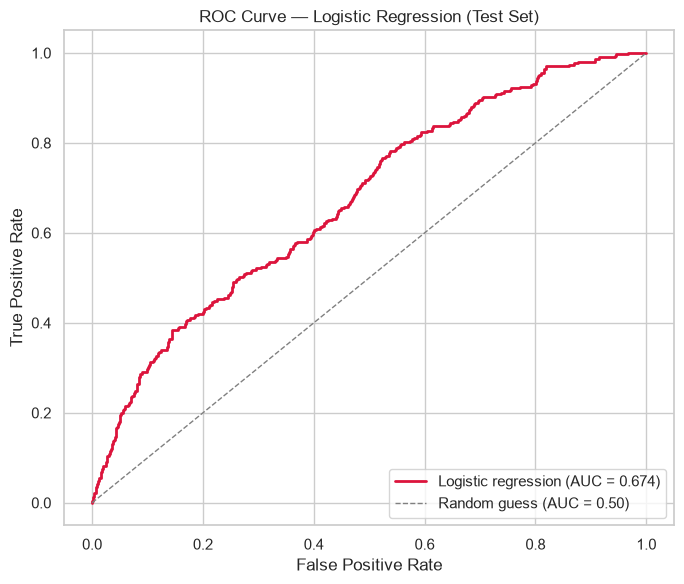

Test AUC: 0.674


In [12]:
X_test_sm = sm.add_constant(X_test, has_constant='add')
test_probs = logit_result.predict(X_test_sm)

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'Logistic regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Test AUC: {auc:.3f}")

Starting with 10 features, initial AUC: 0.674

--- Iteration 1 ---
Current features count: 10
Feature with highest p-value: 'revol.util' (p=0.387)
AUC with 'revol.util' removed: 0.674
AUC improved from 0.674 to 0.674. Removing 'revol.util'.

--- Iteration 2 ---
Current features count: 9
Feature with highest p-value: 'dti' (p=0.304)
AUC with 'dti' removed: 0.674
AUC did not improve (0.674 <= 0.674). Stopping feature elimination.


--- Final Optimized Model ---
Optimal features: ['installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec']
Best AUC achieved: 0.674

Final optimized model summary:
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 7662
Model:                          Logit   Df Residuals:                     7652
Method:                           MLE   Df Model:                            9
Date:             

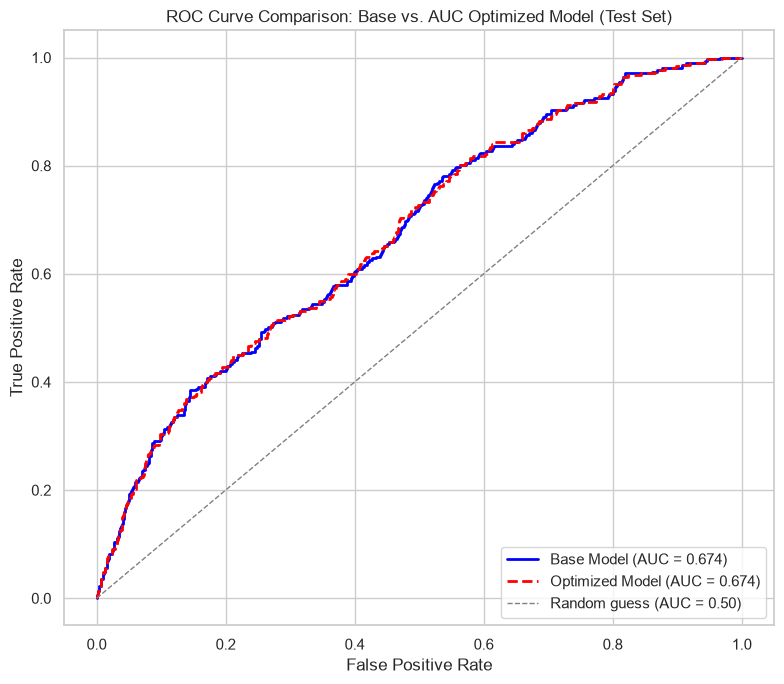

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

# Store base model results
base_logit_result = logit_result
base_auc = auc
base_test_probs = test_probs # from cell 4e388977
base_features = list(model_vars) # from cell 6232e865

current_features = list(base_features)
optimal_features = list(base_features)

best_auc = base_auc

print(f"Starting with {len(current_features)} features, initial AUC: {best_auc:.3f}\n")

iteration = 0
while True:
    iteration += 1
    print(f"--- Iteration {iteration} ---")

    # 1. Fit model with current features
    X_train_current_sm = sm.add_constant(X_train[current_features])
    current_logit_model = sm.Logit(y_train, X_train_current_sm)
    current_logit_result = current_logit_model.fit(disp=False)

    # Get p-values, excluding the constant term
    p_values = current_logit_result.pvalues.drop('const', errors='ignore')

    # If no features or only one feature (constant) left, break
    if p_values.empty:
        print("No more features to consider for removal.\n")
        break

    # Sort features by p-value in descending order
    p_values_sorted = p_values.sort_values(ascending=False)

    # Identify feature with highest p-value
    feature_to_remove = p_values_sorted.index[0]
    highest_p_value = p_values_sorted.iloc[0]

    print(f"Current features count: {len(current_features)}")
    print(f"Feature with highest p-value: '{feature_to_remove}' (p={highest_p_value:.3f})")

    if len(current_features) == 1:
        print("Only one feature remaining. Cannot remove more and expect improvement.\n")
        break

    # Create a temporary feature set by removing the feature with the highest p-value
    temp_features = [f for f in current_features if f != feature_to_remove]

    # 2. Fit a temporary model with the reduced feature set
    X_train_temp_sm = sm.add_constant(X_train[temp_features])
    temp_logit_model = sm.Logit(y_train, X_train_temp_sm)
    temp_logit_result = temp_logit_model.fit(disp=False)

    # 3. Calculate AUC for the temporary model on the test set
    X_test_temp_sm = sm.add_constant(X_test[temp_features])
    temp_test_probs = temp_logit_result.predict(X_test_temp_sm)
    temp_auc = roc_auc_score(y_test, temp_test_probs)

    print(f"AUC with '{feature_to_remove}' removed: {temp_auc:.3f}")

    # 4. Compare AUCs
    if temp_auc > best_auc:
        print(f"AUC improved from {best_auc:.3f} to {temp_auc:.3f}. Removing '{feature_to_remove}'.\n")
        best_auc = temp_auc
        current_features = temp_features
        optimal_features = temp_features # Update optimal features
    else:
        print(f"AUC did not improve ({temp_auc:.3f} <= {best_auc:.3f}). Stopping feature elimination.\n")
        break

print("\n--- Final Optimized Model ---")
print(f"Optimal features: {optimal_features}")
print(f"Best AUC achieved: {best_auc:.3f}")

# Fit the final model with the optimal features
X_train_final_sm = sm.add_constant(X_train[optimal_features])
final_logit_model = sm.Logit(y_train, X_train_final_sm)
final_logit_result = final_logit_model.fit(disp=False)

print("\nFinal optimized model summary:")
print(final_logit_result.summary())

# --- Comparison with Base Model ---
print("\n--- Model Comparison ---")
print(f"Base Model AUC: {base_auc:.3f}")
print(f"Optimized Model AUC: {best_auc:.3f}")
print(f"AUC Improvement: {best_auc - base_auc:.3f}")

# Generate ROC curves for comparison
X_test_final_sm = sm.add_constant(X_test[optimal_features])
final_test_probs = final_logit_result.predict(X_test_final_sm)

fpr_base, tpr_base, _ = roc_curve(y_test, base_test_probs)
fpr_optimized, tpr_optimized, _ = roc_curve(y_test, final_test_probs)

plt.figure(figsize=(8, 7))
plt.plot(fpr_base, tpr_base, color='blue', lw=2, label=f'Base Model (AUC = {base_auc:.3f})')
plt.plot(fpr_optimized, tpr_optimized, color='red', lw=2, linestyle='--', label=f'Optimized Model (AUC = {best_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random guess (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Base vs. AUC Optimized Model (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

### 1.3.2 Standardized coefficients — ranking feature importance

Raw coefficients aren't comparable across variables on very different
scales (e.g. `installment` in dollars vs. `dti` as a ratio). We
standardize each feature (zero mean, unit variance) on the training data
and refit, so coefficient magnitude directly reflects each variable's
impact on default log-odds per one standard deviation of change.

In [14]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=model_vars, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=model_vars, index=X_test.index)

X_train_scaled_sm = sm.add_constant(X_train_scaled)
logit_model_scaled = sm.Logit(y_train, X_train_scaled_sm)
logit_result_scaled = logit_model_scaled.fit(disp=False)
print(logit_result_scaled.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 7662
Model:                          Logit   Df Residuals:                     7651
Method:                           MLE   Df Model:                           10
Date:                Fri, 25 Sep 2026   Pseudo R-squ.:                 0.05228
Time:                        18:24:17   Log-Likelihood:                -3192.8
converged:                       True   LL-Null:                       -3368.9
Covariance Type:            nonrobust   LLR p-value:                 1.325e-69
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.7689      0.034    -51.824      0.000      -1.836      -1.702
installment           0.2490      0.036      6.963      0.000       0.179       0.319
log.annual.inc       -0.

In [15]:
coef_summary = pd.DataFrame({
    'coefficient': logit_result_scaled.params,
    'p_value': logit_result_scaled.pvalues,
}).drop(index='const')
coef_summary['abs_coefficient'] = coef_summary['coefficient'].abs()
coef_summary['odds_ratio_per_sd'] = np.exp(coef_summary['coefficient'])
coef_summary['significant_5pct'] = coef_summary['p_value'] < 0.05
coef_summary = coef_summary.sort_values('abs_coefficient', ascending=False)

display(coef_summary[['coefficient', 'odds_ratio_per_sd', 'p_value', 'significant_5pct']].round(4))

,coefficient,odds_ratio_per_sd,p_value,significant_5pct
fico,-0.3876,0.6787,0.0000,True
inq.last.6mths,0.2806,1.3239,0.0000,True
log.annual.inc,-0.2527,0.7767,0.0000,True
installment,0.2490,1.2827,0.0000,True
revol.bal,0.1579,1.1710,0.0000,True
days.with.cr.line,0.0544,1.0559,0.1348,False
pub.rec,0.0515,1.0528,0.0729,False
dti,-0.0412,0.9597,0.2368,False
revol.util,0.0352,1.0358,0.3867,False
delinq.2yrs,-0.0336,0.9670,0.3017,False


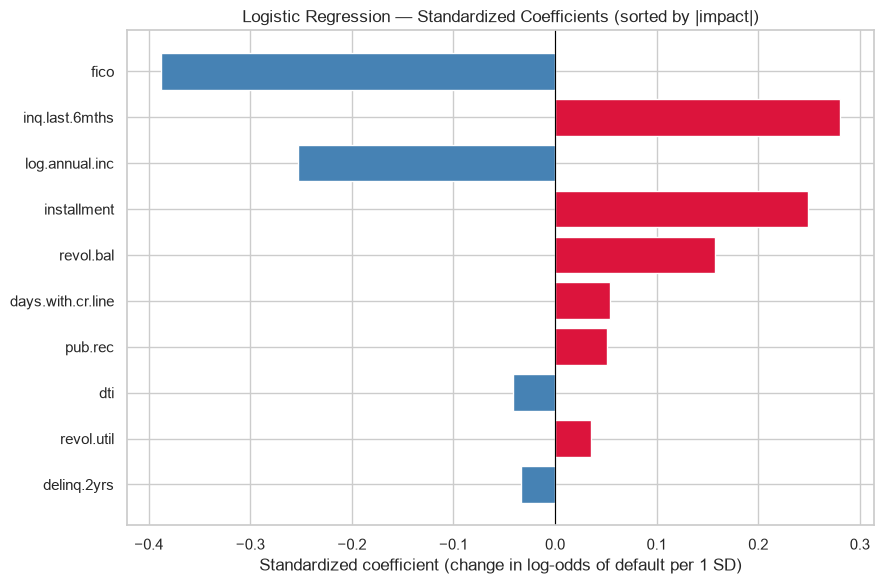

In [16]:
plt.figure(figsize=(9, 6))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_summary['coefficient']]
plt.barh(coef_summary.index[::-1], coef_summary['coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardized coefficient (change in log-odds of default per 1 SD)')
plt.title('Logistic Regression — Standardized Coefficients (sorted by |impact|)')
plt.tight_layout()
plt.show()

### 1.3.3 Probability of default vs. top 3 features

For each of the three highest-impact features (by |standardized
coefficient|), we vary that feature across its observed range while
holding all other features at their training-set median, and plot the
model's predicted default probability. This isolates each feature's
marginal effect on predicted risk.

Top 3 features by |standardized coefficient|: ['fico', 'inq.last.6mths', 'log.annual.inc']


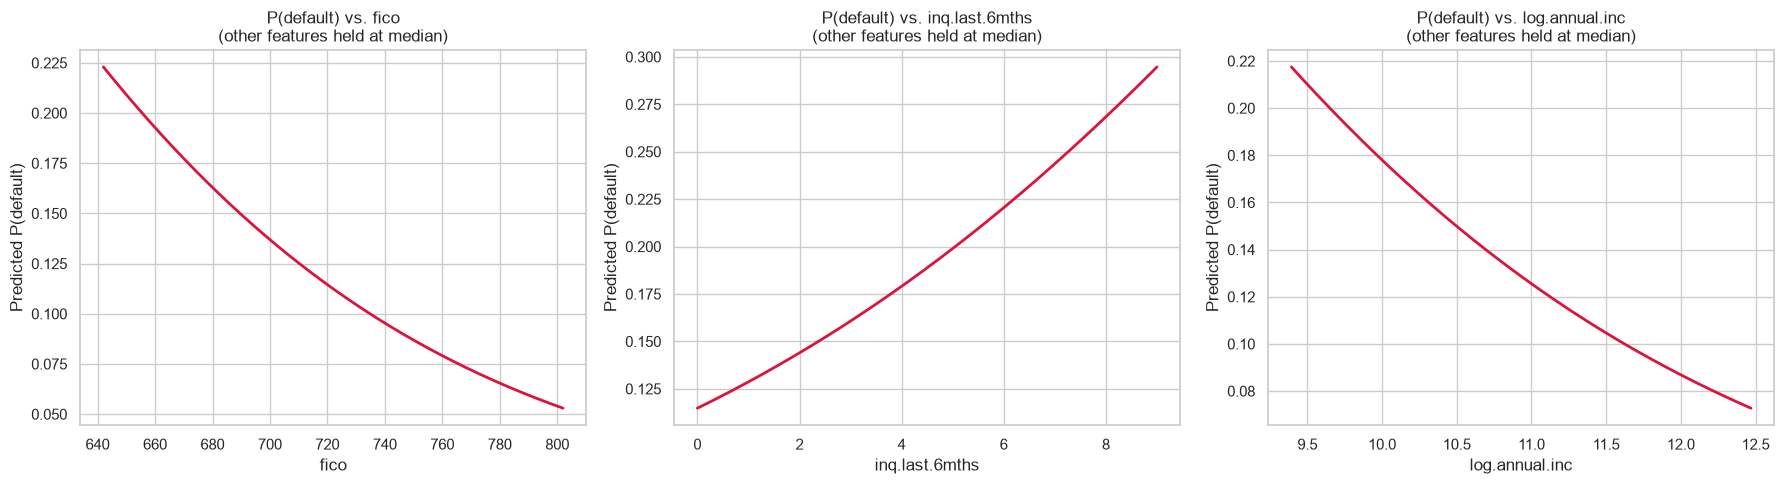

In [17]:
top3_features = coef_summary.index[:3].tolist()
print("Top 3 features by |standardized coefficient|:", top3_features)

median_row_raw = X_train.median()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3_features):
    feat_range = np.linspace(X_train[feat].quantile(0.01), X_train[feat].quantile(0.99), 200)
    grid = pd.DataFrame([median_row_raw.values] * len(feat_range), columns=model_vars)
    grid[feat] = feat_range
    grid_sm = sm.add_constant(grid, has_constant='add')
    pred_prob = logit_result.predict(grid_sm)

    ax.plot(feat_range, pred_prob, color='crimson', lw=2)
    ax.set_xlabel(feat)
    ax.set_ylabel('Predicted P(default)')
    ax.set_title(f'P(default) vs. {feat}\n(other features held at median)')
    ax.grid(True)

plt.tight_layout()
plt.show()

### 1.3.4 Multicollinearity check — Variance Inflation Factor (VIF)

The pairwise correlation check in Section 2.1 only looks at two variables
at a time. VIF captures multicollinearity involving combinations of three
or more variables by regressing each feature on all the others.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df['feature'] = model_vars
vif_df['VIF'] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(len(model_vars))]
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
display(vif_df.round(2))

,feature,VIF
0,fico,1.93
1,revol.util,1.70
2,log.annual.inc,1.51
3,days.with.cr.line,1.30
4,installment,1.28
5,revol.bal,1.28
6,dti,1.20
7,delinq.2yrs,1.14
8,inq.last.6mths,1.07
9,pub.rec,1.05


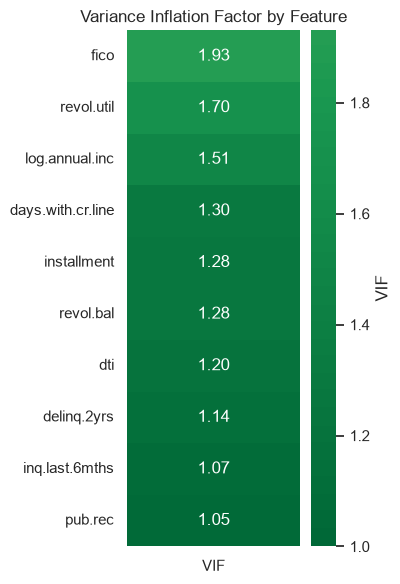

Rule of thumb: VIF > 5 warrants a closer look; VIF > 10 indicates serious multicollinearity.


In [19]:
vif_heatmap_data = vif_df.set_index('feature')[['VIF']]

plt.figure(figsize=(4, 6))
sns.heatmap(vif_heatmap_data, annot=True, fmt=".2f", cmap='RdYlGn_r',
            center=5, vmin=1, cbar_kws={'label': 'VIF'})
plt.title('Variance Inflation Factor by Feature')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("Rule of thumb: VIF > 5 warrants a closer look; VIF > 10 indicates serious multicollinearity.")

### 1.3.5 Lift chart (test set)

The lift chart ranks test-set loans by predicted default probability
(highest risk first), splits them into deciles, and compares the actual
default rate in each decile to the overall base rate. A useful model
concentrates actual defaulters in the top (highest-predicted-risk)
deciles.

,decile,n_loans,n_defaults,default_rate,lift
0,1,192,73,0.380,2.373
1,2,192,47,0.245,1.528
2,3,191,33,0.173,1.078
3,4,192,24,0.125,0.780
4,5,191,29,0.152,0.948
5,6,192,39,0.203,1.268
6,7,191,18,0.094,0.588
7,8,192,21,0.109,0.683
8,9,191,17,0.089,0.555
9,10,192,6,0.031,0.195


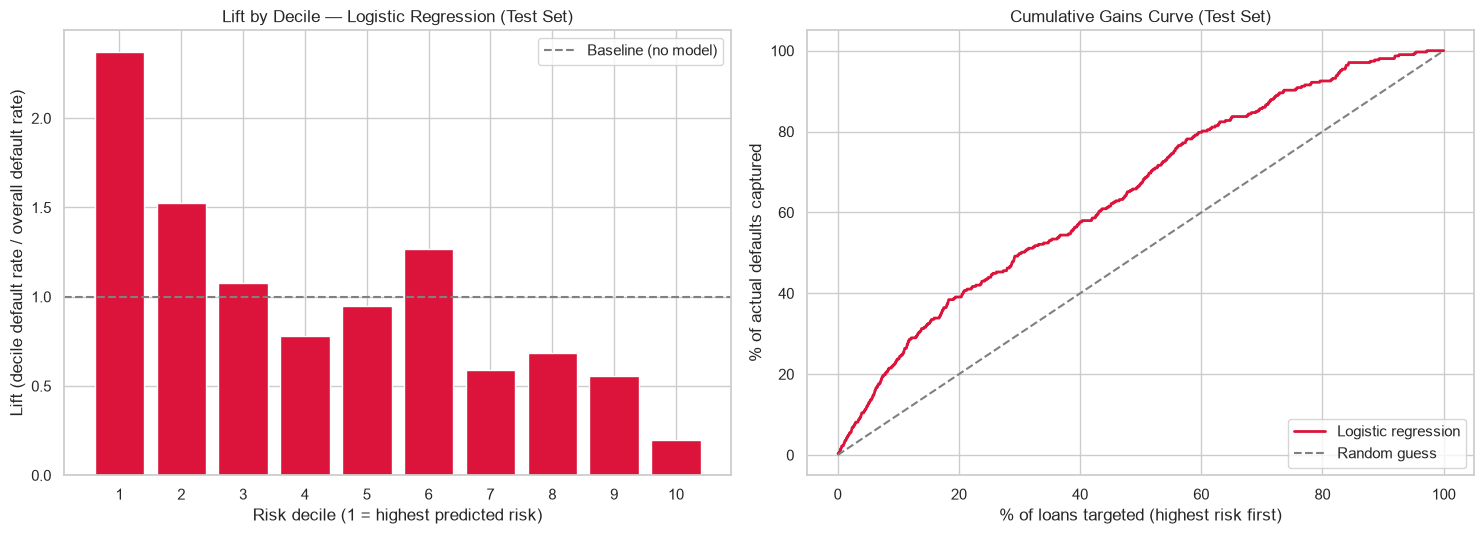

In [20]:
lift_df = pd.DataFrame({'y_true': y_test.values, 'pred_prob': test_probs.values})
lift_df = lift_df.sort_values('pred_prob', ascending=False).reset_index(drop=True)
lift_df['decile'] = pd.qcut(lift_df.index, 10, labels=False) + 1  # 1 = highest risk

overall_rate = lift_df['y_true'].mean()
decile_summary = lift_df.groupby('decile').agg(
    n_loans=('y_true', 'size'),
    n_defaults=('y_true', 'sum'),
    default_rate=('y_true', 'mean'),
).reset_index()
decile_summary['lift'] = decile_summary['default_rate'] / overall_rate

display(decile_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

axes[0].bar(decile_summary['decile'], decile_summary['lift'], color='crimson')
axes[0].axhline(1.0, color='gray', linestyle='--', label='Baseline (no model)')
axes[0].set_xlabel('Risk decile (1 = highest predicted risk)')
axes[0].set_ylabel('Lift (decile default rate / overall default rate)')
axes[0].set_title('Lift by Decile — Logistic Regression (Test Set)')
axes[0].set_xticks(range(1, 11))
axes[0].legend()

lift_df['cum_defaults'] = lift_df['y_true'].cumsum()
lift_df['cum_pct_loans'] = (np.arange(1, len(lift_df) + 1)) / len(lift_df) * 100
lift_df['cum_pct_defaults'] = lift_df['cum_defaults'] / lift_df['y_true'].sum() * 100

axes[1].plot(lift_df['cum_pct_loans'], lift_df['cum_pct_defaults'], color='crimson', lw=2,
             label='Logistic regression')
axes[1].plot([0, 100], [0, 100], color='gray', linestyle='--', label='Random guess')
axes[1].set_xlabel('% of loans targeted (highest risk first)')
axes[1].set_ylabel('% of actual defaults captured')
axes[1].set_title('Cumulative Gains Curve (Test Set)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 2. Decision Tree

# 3. Comparison and Random Forest